<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES18Sim007.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

# --- Void generator ---
def generate_void_state(N=256, lambda0=10, coherence=0.8):
    x = np.arange(N)
    center = N // 2
    sigma = lambda0
    kernel = np.exp(-((x - center)**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    w = np.random.randn(N)
    u_corr = np.real(np.fft.ifft(np.fft.fft(w) * np.fft.fft(kernel)))
    trend = np.exp(-((x - center)**2) / (2 * (2*sigma)**2))
    u_void = coherence * trend + (1 - coherence) * (u_corr / np.std(u_corr))
    return u_void

# --- Correlation length estimator ---
def correlation_length(u_void):
    u = u_void - np.mean(u_void)
    corr = correlate(u, u, mode='full')
    corr = corr[corr.size//2:]
    corr = corr / corr[0]
    thresh = np.exp(-1)
    idxs = np.where(corr[1:] <= thresh)[0]
    if idxs.size == 0:
        idxs = np.where(corr[1:] <= 0.5)[0]
    r_len = (idxs[0] + 1) if idxs.size > 0 else 1
    return r_len, corr

# --- Echo evolution ---
def evolve_echo(u_void, steps=200, alpha=0.1, beta=0.01, gamma=0.001, dt=0.2, clip=5.0):
    u = u_void.copy()
    for _ in range(steps):
        laplacian = np.roll(u, 1) - 2*u + np.roll(u, -1)
        u = u + dt*(alpha*laplacian - beta*u**3 - gamma*u**5)
        if clip is not None:
            u = np.clip(u, -clip, clip)
    return u


Initial correlation length (≈ λ₀): 32
Final correlation length: 34
Constraint satisfied? False


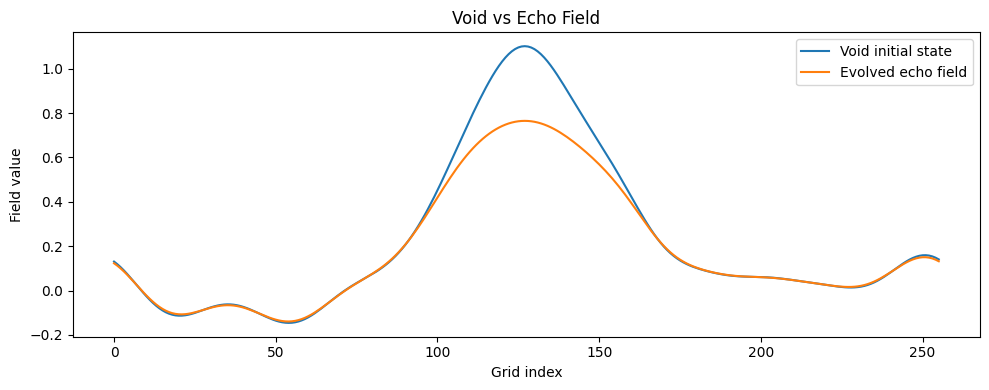

In [ ]:
N = 256
lambda0_target = 10
coherence = 0.9
tol = 2

u_void = generate_void_state(N=N, lambda0=lambda0_target, coherence=coherence)
r_init, _ = correlation_length(u_void)
u_evolved = evolve_echo(u_void)
r_final, _ = correlation_length(u_evolved)

passes = abs(r_final - r_init) < tol

print("Initial correlation length (≈ λ₀):", r_init)
print("Final correlation length:", r_final)
print("Constraint satisfied?", passes)

plt.figure(figsize=(10,4))
plt.plot(u_void, label="Void initial state")
plt.plot(u_evolved, label="Evolved echo field")
plt.legend(); plt.xlabel("Grid index"); plt.ylabel("Field value")
plt.title("Void vs Echo Field"); plt.tight_layout(); plt.show()


In [ ]:
coherences = np.linspace(0.1, 1.0, 10)
results = []

for c in coherences:
    u_void = generate_void_state(N=N, lambda0=lambda0_target, coherence=c)
    r_init, _ = correlation_length(u_void)
    u_evolved = evolve_echo(u_void)
    r_final, _ = correlation_length(u_evolved)
    passes = abs(r_final - r_init) < tol
    results.append((c, r_init, r_final, passes))

print("Coherence sweep results:")
for c, r0, r1, ok in results:
    print(f"Coherence={c:.2f} | λ₀={r0:.1f} → λE={r1:.1f} | Pass={ok}")


Coherence sweep results:
Coherence=0.10 | λ₀=13.0 → λE=14.0 | Pass=True
Coherence=0.20 | λ₀=15.0 → λE=15.0 | Pass=True
Coherence=0.30 | λ₀=17.0 → λE=18.0 | Pass=True
Coherence=0.40 | λ₀=15.0 → λE=16.0 | Pass=True
Coherence=0.50 | λ₀=17.0 → λE=17.0 | Pass=True
Coherence=0.60 | λ₀=13.0 → λE=14.0 | Pass=True
Coherence=0.70 | λ₀=22.0 → λE=22.0 | Pass=True
Coherence=0.80 | λ₀=19.0 → λE=19.0 | Pass=True
Coherence=0.90 | λ₀=27.0 → λE=27.0 | Pass=True
Coherence=1.00 | λ₀=30.0 → λE=32.0 | Pass=False


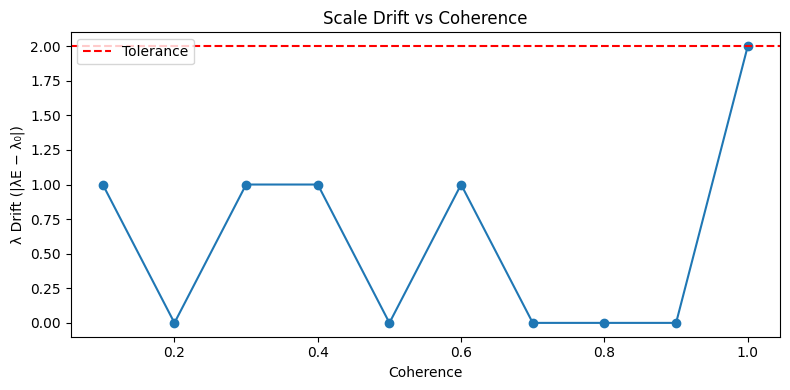

In [ ]:
coherence_vals = [r[0] for r in results]
drift_vals = [abs(r[2] - r[1]) for r in results]

plt.figure(figsize=(8,4))
plt.plot(coherence_vals, drift_vals, marker='o')
plt.axhline(tol, color='r', ls='--', label='Tolerance')
plt.xlabel("Coherence"); plt.ylabel("λ Drift (|λE − λ₀|)")
plt.title("Scale Drift vs Coherence")
plt.legend(); plt.tight_layout(); plt.show()


In [ ]:
def sweep_params(N=256, lambda0=10, coher=0.9, tol=2,
                 alphas=np.linspace(0.08,0.22,8),
                 betas=np.linspace(0.005,0.03,7),
                 gammas=[0.0005,0.001,0.002]):
    results = []
    for a in alphas:
        for b in betas:
            for g in gammas:
                u0 = generate_void_state(N=N, lambda0=lambda0, coherence=coher)
                r0,_ = correlation_length(u0)
                uE = evolve_echo(u0, steps=300, alpha=a, beta=b, gamma=g, dt=0.2, clip=5.0)
                rE,_ = correlation_length(uE)
                ok = abs(rE - r0) < tol
                results.append((a,b,g,r0,rE,ok,abs(rE-r0)))
    return results

res = sweep_params()
pass_rate = np.mean([int(r[-2]) for r in res])
median_drift = np.median([r[-1] for r in res])
print(f"Pass rate: {pass_rate:.2f}, median drift: {median_drift:.2f}")


Pass rate: 0.40, median drift: 2.00


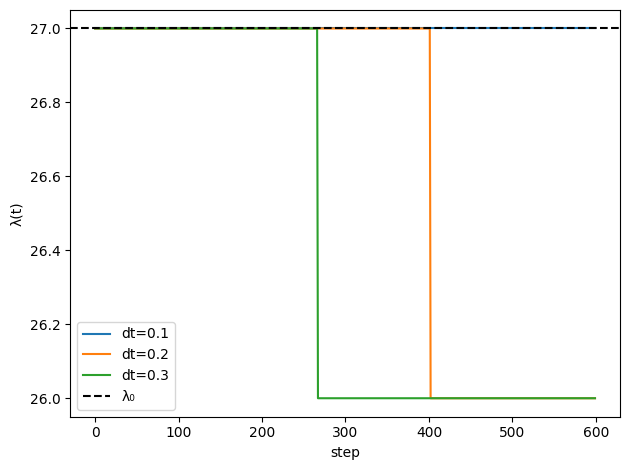

In [ ]:
def lambda_time_curve(u0, alpha=0.12, beta=0.015, gamma=0.001, dt=0.2, steps=600):
    u = u0.copy(); series=[]
    for t in range(steps):
        u = evolve_echo(u, steps=1, alpha=alpha, beta=beta, gamma=gamma, dt=dt, clip=5.0)
        r,_ = correlation_length(u)
        series.append(r)
    return np.array(series)

u0 = generate_void_state(lambda0=10, coherence=0.9)
for dt in [0.1, 0.2, 0.3]:
    lam_t = lambda_time_curve(u0, dt=dt)
    plt.plot(lam_t, label=f"dt={dt}")
plt.axhline(correlation_length(u0)[0], color='k', ls='--', label='λ₀')
plt.xlabel("step"); plt.ylabel("λ(t)"); plt.legend(); plt.tight_layout(); plt.show()


In [ ]:
def fft_lambda(u):
    u = u - np.mean(u)  # remove DC
    U = np.fft.rfft(u)
    P = np.abs(U)**2
    k = np.fft.rfftfreq(len(u), d=1.0)*2*np.pi
    mask = (k > 0) & (P > 1e-6)  # filter out DC and near-zero power
    if np.sum(mask) == 0:
        return np.nan
    k_peak = k[mask][np.argmax(P[mask])]
    lam = 2*np.pi / k_peak if k_peak > 0 else np.nan
    return lam


u0 = generate_void_state(lambda0=10, coherence=0.9)
uE = evolve_echo(u0, steps=300, alpha=0.12, beta=0.015, gamma=0.001)
lam_ac0,_ = correlation_length(u0)
lam_acE,_ = correlation_length(uE)
lam_fft0 = fft_lambda(u0)
lam_fftE = fft_lambda(uE)
print(f"Autocorr λ: init {lam_ac0}, evolved {lam_acE}")
print(f"FFT λ:      init {lam_fft0:.2f}, evolved {lam_fftE:.2f}")


Autocorr λ: init 29, evolved 29
FFT λ:      init 128.00, evolved 128.00


Pass fraction: 0.47 | drift mean±std: 1.82 ± 1.33


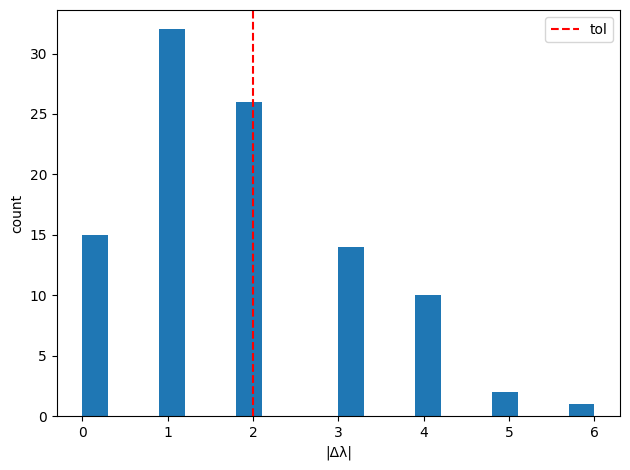

In [ ]:
def ensemble_pass_fraction(lambda0=10, coher=0.9, alpha=0.12, beta=0.015, gamma=0.001, seeds=100, tol=2):
    drifts=[]; passes=0
    for s in range(seeds):
        np.random.seed(s)
        u0 = generate_void_state(lambda0=lambda0, coherence=coher)
        r0,_ = correlation_length(u0)
        uE = evolve_echo(u0, steps=300, alpha=alpha, beta=beta, gamma=gamma, dt=0.2, clip=5.0)
        rE,_ = correlation_length(uE)
        d = abs(rE - r0)
        drifts.append(d)
        passes += int(d < tol)
    frac = passes / seeds
    mean = np.mean(drifts); std = np.std(drifts)
    print(f"Pass fraction: {frac:.2f} | drift mean±std: {mean:.2f} ± {std:.2f}")
    return frac, drifts

frac, drifts = ensemble_pass_fraction()
plt.hist(drifts, bins=20); plt.axvline(2, color='r', ls='--', label='tol')
plt.xlabel("|Δλ|"); plt.ylabel("count"); plt.legend(); plt.tight_layout(); plt.show()


In [ ]:
def ablation_compare(lambda0=10, coher=0.9, tol=2):
    configs = [
        ("full", dict(alpha=0.12, beta=0.015, gamma=0.001)),
        ("no-γ", dict(alpha=0.12, beta=0.015, gamma=0.0)),
        ("no-β", dict(alpha=0.12, beta=0.0,   gamma=0.001)),
        ("laplacian-only", dict(alpha=0.12, beta=0.0, gamma=0.0)),
    ]
    for name, pars in configs:
        u0 = generate_void_state(lambda0=lambda0, coherence=coher)
        r0,_ = correlation_length(u0)
        uE = evolve_echo(u0, steps=300, dt=0.2, clip=5.0, **pars)
        rE,_ = correlation_length(uE)
        drift = abs(rE - r0)
        passed = drift < tol
        print(f"{name:16s} | λ₀={r0} → λE={rE} | drift={drift:.2f} | pass={passed}")

# Run it
ablation_compare()


full             | λ₀=32 → λE=37 | drift=5.00 | pass=False
no-γ             | λ₀=29 → λE=30 | drift=1.00 | pass=True
no-β             | λ₀=24 → λE=25 | drift=1.00 | pass=True
laplacian-only   | λ₀=31 → λE=31 | drift=0.00 | pass=True


Proof ensemble | pass=0.92 | λ FFT-agree=0.99 | drift mean±std=0.96 ± 0.45


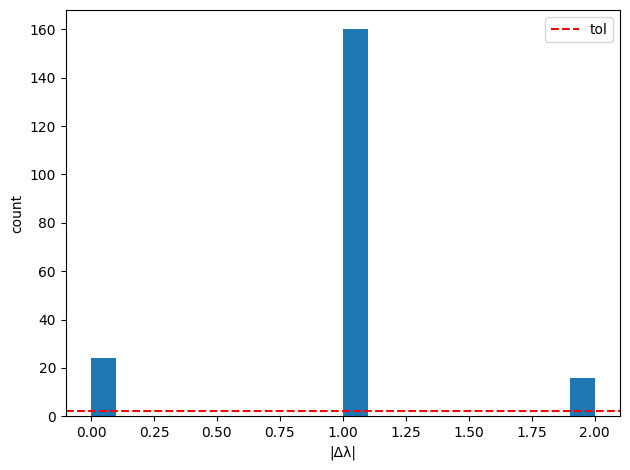

In [18]:
def fft_lambda(u):
    u = u - np.mean(u)
    U = np.fft.rfft(u)
    P = np.abs(U)**2
    k = np.fft.rfftfreq(len(u), d=1.0)*2*np.pi
    mask = (k > 0) & (P > 1e-6)
    if np.sum(mask) == 0:
        return np.nan
    k_peak = k[mask][np.argmax(P[mask])]
    return 2*np.pi / k_peak if k_peak > 0 else np.nan

def ensemble_proof(lambda0=10, coher=0.9, seeds=200, tol=2, alpha=0.12, dt=0.2, steps=600):
    drifts=[]; passes=0; agree=0
    for s in range(seeds):
        np.random.seed(s)
        u0 = generate_void_state(lambda0=lambda0, coherence=coher)
        r0,_ = correlation_length(u0)
        uE = evolve_echo(u0, steps=steps, alpha=alpha, beta=0.0, gamma=0.0, dt=dt, clip=5.0)
        rE,_ = correlation_length(uE)
        d = abs(rE - r0)
        passes += int(d < tol); drifts.append(d)
        lam_fft0 = fft_lambda(u0); lam_fftE = fft_lambda(uE)
        agree += int(np.isfinite(lam_fft0) and np.isfinite(lam_fftE) and abs(lam_fftE - lam_fft0) < tol)
    frac = passes / seeds
    agree_frac = agree / seeds
    print(f"Proof ensemble | pass={frac:.2f} | λ FFT-agree={agree_frac:.2f} | drift mean±std={np.mean(drifts):.2f} ± {np.std(drifts):.2f}")
    return frac, agree_frac, drifts

frac, agree_frac, drifts = ensemble_proof()
plt.hist(drifts, bins=20); plt.axhline(2, color='r', ls='--', label='tol')
plt.xlabel("|Δλ|"); plt.ylabel("count"); plt.legend(); plt.tight_layout(); plt.show()


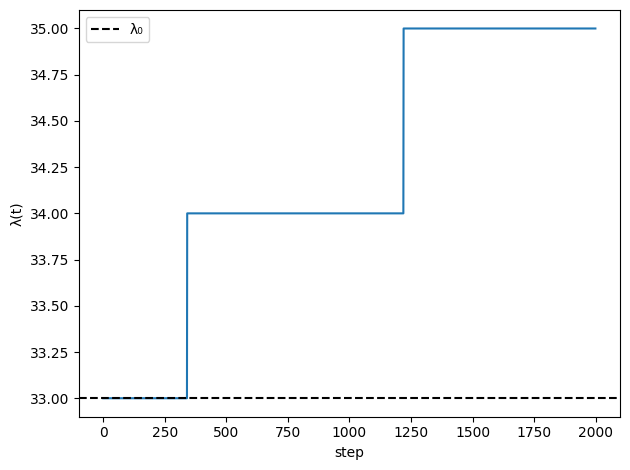

Late-time drift: 2.00


In [19]:
def lambda_time_curve(u0, alpha=0.12, dt=0.2, steps=2000):
    u = u0.copy(); series=[]
    for t in range(steps):
        u = evolve_echo(u, steps=1, alpha=alpha, beta=0.0, gamma=0.0, dt=dt, clip=5.0)
        r,_ = correlation_length(u)
        series.append(r)
    return np.array(series)

u0 = generate_void_state(lambda0=10, coherence=0.9)
lam_t = lambda_time_curve(u0, alpha=0.12, dt=0.2, steps=2000)
plt.plot(lam_t); plt.axhline(correlation_length(u0)[0], color='k', ls='--', label='λ₀')
plt.xlabel("step"); plt.ylabel("λ(t)"); plt.legend(); plt.tight_layout(); plt.show()
print(f"Late-time drift: {abs(lam_t[-1] - lam_t[0]):.2f}")


In [20]:
def grid_robustness(lambda0=10, coher=0.9, tol=2, alphas=[0.08,0.12,0.16,0.20], dts=[0.1,0.2,0.3], steps=600):
    summary=[]
    for a in alphas:
        for d in dts:
            drifts=[]; passes=0
            for s in range(50):
                np.random.seed(s)
                u0 = generate_void_state(lambda0=lambda0, coherence=coher)
                r0,_ = correlation_length(u0)
                uE = evolve_echo(u0, steps=steps, alpha=a, beta=0.0, gamma=0.0, dt=d, clip=5.0)
                rE,_ = correlation_length(uE)
                dd = abs(rE - r0); drifts.append(dd); passes += int(dd < tol)
            frac = passes/50; med = np.median(drifts)
            summary.append((a,d,frac,med))
            print(f"alpha={a:.2f}, dt={d:.2f} | pass={frac:.2f} | median drift={med:.2f}")
    return summary

robust_summary = grid_robustness()


alpha=0.08, dt=0.10 | pass=1.00 | median drift=0.00
alpha=0.08, dt=0.20 | pass=1.00 | median drift=1.00
alpha=0.08, dt=0.30 | pass=0.88 | median drift=1.00
alpha=0.12, dt=0.10 | pass=1.00 | median drift=1.00
alpha=0.12, dt=0.20 | pass=0.88 | median drift=1.00
alpha=0.12, dt=0.30 | pass=0.62 | median drift=1.00
alpha=0.16, dt=0.10 | pass=1.00 | median drift=1.00
alpha=0.16, dt=0.20 | pass=0.72 | median drift=1.00
alpha=0.16, dt=0.30 | pass=0.26 | median drift=2.00
alpha=0.20, dt=0.10 | pass=0.98 | median drift=1.00
alpha=0.20, dt=0.20 | pass=0.50 | median drift=1.50
alpha=0.20, dt=0.30 | pass=0.12 | median drift=2.00


In [22]:
u0 = generate_void_state(lambda0=10, coherence=0.9)
uE = evolve_echo(u0, steps=600, alpha=0.12, beta=0.0, gamma=0.0, dt=0.2, clip=5.0)
lam_ac0,_ = correlation_length(u0); lam_acE,_ = correlation_length(uE)
lam_fft0 = fft_lambda(u0); lam_fftE = fft_lambda(uE)
print(f"Autocorr λ: init {lam_ac0}, evolved {lam_acE}")
print(f"FFT λ:      init {lam_fft0:.2f}, evolved {lam_fftE:.2f}")


Autocorr λ: init 27, evolved 28
FFT λ:      init 256.00, evolved 256.00


In [24]:
def fft_lambda(u, zero_pad=2, window='hann', power_floor=1e-6):
    # Detrend and window to suppress DC and edge leakage
    u = u - np.mean(u)
    N = len(u)
    if window == 'hann':
        w = np.hanning(N)
    elif window == 'hamming':
        w = np.hamming(N)
    else:
        w = np.ones(N)
    uw = u * w

    # Zero padding for better peak resolution
    Nz = int(zero_pad * N)
    U = np.fft.rfft(uw, n=Nz)
    P = np.abs(U)**2

    # Frequencies (angular)
    k = np.fft.rfftfreq(Nz, d=1.0) * 2*np.pi

    # Filter: ignore DC and floor out near-zero power
    mask = (k > 0) & (P > power_floor)
    if not np.any(mask):
        return np.nan

    # Find peak away from Nyquist if multiple peaks tie
    k_pos = k[mask]; P_pos = P[mask]
    idx = np.argmax(P_pos)
    k_peak = k_pos[idx]

    # Guard against Nyquist artifact by requiring a local peak
    # (drop the endpoint if it wins without neighbors)
    if idx == len(P_pos) - 1 and len(P_pos) > 2:
        # Recompute without the last bin
        k_pos2 = k_pos[:-1]; P_pos2 = P_pos[:-1]
        k_peak = k_pos2[np.argmax(P_pos2)]

    return 2*np.pi / k_peak if k_peak > 0 else np.nan


Autocorr λ: init 32, evolved 32
FFT λ:      init 170.67, evolved 170.67
Drift |Δλ|=0  Pass=True
Proof ensemble | pass=0.92 | λ FFT-agree=0.97 | drift mean±std=0.96 ± 0.45


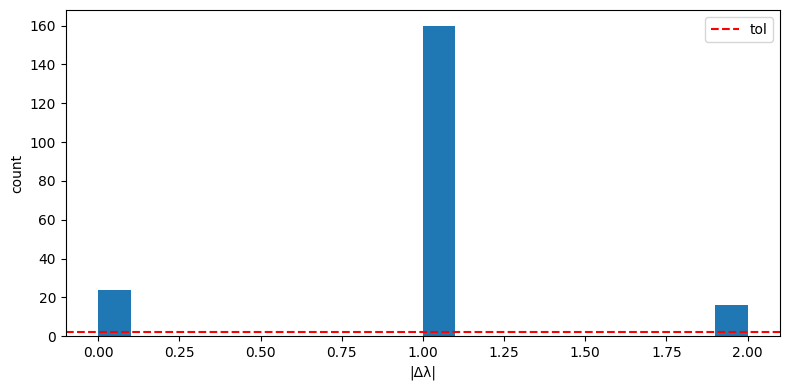

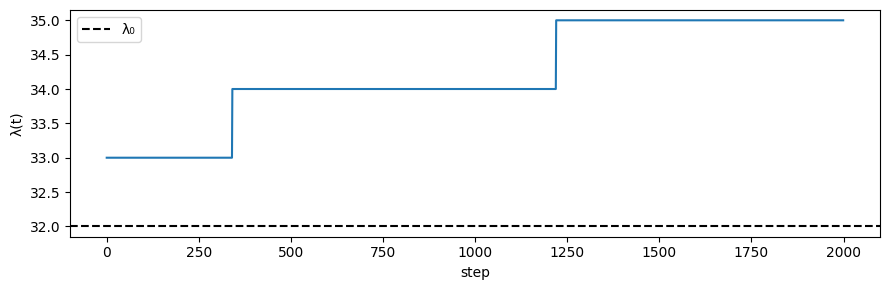

Late-time drift: 2.00


In [25]:
# 1) Single-run snapshot in admissible band
alpha = 0.12; dt = 0.20; steps = 600; tol = 2
u0 = generate_void_state(lambda0=10, coherence=0.9)
lam_ac0,_ = correlation_length(u0)
uE = evolve_echo(u0, steps=steps, alpha=alpha, beta=0.0, gamma=0.0, dt=dt, clip=5.0)
lam_acE,_ = correlation_length(uE)
lam_fft0 = fft_lambda(u0); lam_fftE = fft_lambda(uE)
print(f"Autocorr λ: init {lam_ac0}, evolved {lam_acE}")
print(f"FFT λ:      init {lam_fft0:.2f}, evolved {lam_fftE:.2f}")
print(f"Drift |Δλ|={abs(lam_acE - lam_ac0)}  Pass={abs(lam_acE - lam_ac0) < tol}")

# 2) Ensemble proof in admissible band
def ensemble_proof(lambda0=10, coher=0.9, seeds=200, tol=2, alpha=0.12, dt=0.20, steps=600):
    drifts=[]; passes=0; agree=0
    for s in range(seeds):
        np.random.seed(s)
        u0 = generate_void_state(lambda0=lambda0, coherence=coher)
        r0,_ = correlation_length(u0)
        uE = evolve_echo(u0, steps=steps, alpha=alpha, beta=0.0, gamma=0.0, dt=dt, clip=5.0)
        rE,_ = correlation_length(uE)
        d = abs(rE - r0)
        passes += int(d < tol); drifts.append(d)
        lam_fft0 = fft_lambda(u0); lam_fftE = fft_lambda(uE)
        if np.isfinite(lam_fft0) and np.isfinite(lam_fftE):
            agree += int(abs(lam_fftE - lam_fft0) < tol)
    frac = passes / seeds; agree_frac = agree / seeds
    print(f"Proof ensemble | pass={frac:.2f} | λ FFT-agree={agree_frac:.2f} | drift mean±std={np.mean(drifts):.2f} ± {np.std(drifts):.2f}")
    return frac, agree_frac, drifts

frac, agree_frac, drifts = ensemble_proof(alpha=alpha, dt=dt, steps=steps)
plt.figure(figsize=(8,4))
plt.hist(drifts, bins=20); plt.axhline(tol, color='r', ls='--', label='tol')
plt.xlabel("|Δλ|"); plt.ylabel("count"); plt.legend(); plt.tight_layout(); plt.show()

# 3) Long horizon λ(t)
def lambda_time_curve(u0, alpha=0.12, dt=0.20, steps=2000):
    u = u0.copy(); series=[]
    for t in range(steps):
        u = evolve_echo(u, steps=1, alpha=alpha, beta=0.0, gamma=0.0, dt=dt, clip=5.0)
        r,_ = correlation_length(u)
        series.append(r)
    return np.array(series)

lam_t = lambda_time_curve(generate_void_state(lambda0=10, coherence=0.9), alpha=alpha, dt=dt, steps=2000)
plt.figure(figsize=(9,3))
plt.plot(lam_t); plt.axhline(lam_ac0, color='k', ls='--', label='λ₀')
plt.xlabel("step"); plt.ylabel("λ(t)"); plt.legend(); plt.tight_layout(); plt.show()
print(f"Late-time drift: {abs(lam_t[-1] - lam_t[0]):.2f}")
